In [1]:

import numpy as np
import sys, os
sys.path.append(os.path.abspath(".."))

import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.animation import PillowWriter
from matplotlib.colors import LogNorm
import matplotlib.cm as cm
from matplotlib import patches
from astropy.wcs.utils import pixel_to_skycoord, skycoord_to_pixel
from regions import CircleSkyRegion, CirclePixelRegion
from scipy.interpolate import interp1d
import healpy as hp
# from reproject import reproject_from_healpix
import json

import astropy
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import Angle, SkyCoord
import astropy.units as u
import scipy.ndimage as ndi
from astropy.stats import sigma_clip

from scipy.optimize import curve_fit
from skimage.filters import difference_of_gaussians, gaussian
# from skimage.io import imread, imshow
# from skimage.feature import peak_local_max
# from skimage import color, exposure, transform
from skimage.feature import blob_dog, blob_log, blob_doh
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.backends.backend_pdf as mpdf
from scipy.ndimage import gaussian_filter
from scipy.spatial.distance import cdist

from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
from itertools import product
from helpers2 import *
%matplotlib inline

%load_ext autoreload
%autoreload 2
%reload_ext autoreload
milagrotextcolor, milagro = setupMilagroColormap(-3, 15, 2, 256)
milagrotextcolor2, milagro2 = setupMilagroColormap(0.2, 1, 2, 256)

In [2]:
def crop_fits_data(array, wcs, lon_min, lon_max, lat_min, lat_max):
    """
    Crop the FITS array and update WCS based on Galactic lon/lat bounds.
    
    Returns:
        cropped_array : 2D numpy array of the cropped region
        cropped_wcs   : updated WCS object for the cropped region
    """
    from astropy.coordinates import SkyCoord
    import astropy.units as u

    # Convert sky corners to pixel coordinates
    coord_bl = SkyCoord(l=lon_min*u.deg, b=lat_min*u.deg, frame='galactic')
    coord_tr = SkyCoord(l=lon_max*u.deg, b=lat_max*u.deg, frame='galactic')

    x_bl, y_bl = wcs.world_to_pixel(coord_bl)
    x_tr, y_tr = wcs.world_to_pixel(coord_tr)

    # Ensure correct ordering
    x_min_pix = int(min(x_bl, x_tr))
    x_max_pix = int(max(x_bl, x_tr))
    y_min_pix = int(min(y_bl, y_tr))
    y_max_pix = int(max(y_bl, y_tr))

    # Clamp to array bounds
    x_min_pix = max(x_min_pix, 0)
    x_max_pix = min(x_max_pix, array.shape[1])
    y_min_pix = max(y_min_pix, 0)
    y_max_pix = min(y_max_pix, array.shape[0])

    # Slice the array
    cropped_array = array[y_min_pix:y_max_pix, x_min_pix:x_max_pix]

    # Update WCS to reflect the new origin
    cropped_wcs = wcs.slice((slice(y_min_pix, y_max_pix), slice(x_min_pix, x_max_pix)))

    return cropped_array, cropped_wcs


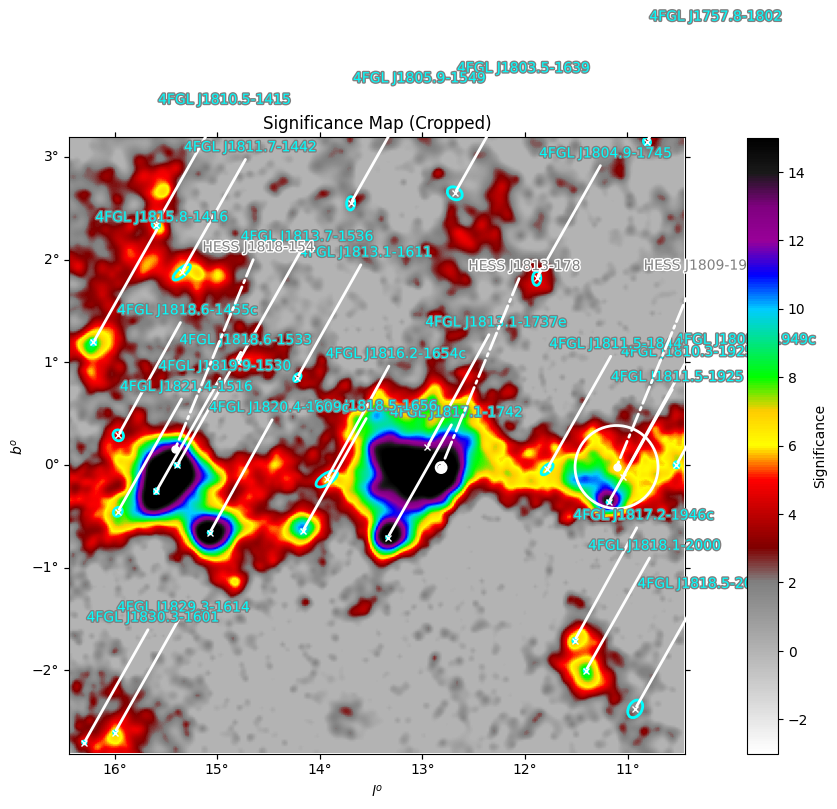

Degrees per pixel: 0.02 
Peak intensity pixel location: (134, 48)
Peak intensity sky location: <SkyCoord (Galactic): (l, b) in deg
    (15.48123844, -0.13012727)>
Peak intensity value: 22.040432696068443
None
Peak intensity pixel location: (134, 48)
Peak intensity sky location: <SkyCoord (Galactic): (l, b) in deg
    (15.48123844, -0.13012727)>
Peak intensity value: 22.040432696068443


In [14]:
filename = '/lustre/hawcz01/scratch/userspace/rbabu/V5512/multi-wavelength/fermi-1813/afterOpt-ROI_pointsource_powerlaw_2.00_tsmap.fits'
fermi_data = fits.open(filename)
header_fermi=fermi_data[4].header
array = fermi_data[4].data
wcs= WCS(fermi_data[4].header)
xnum = array.shape[1]
ynum = array.shape[0]
pixel_size = abs(header_fermi['CDELT1'])

# lon_min, lon_max = 20.0, 30.0  # degrees
# lat_min, lat_max = -4.0,  4.0  # degrees

# array, wcs = crop_fits_data(array, wcs, lon_min, lon_max, lat_min, lat_max)
# xnum = array.shape[1]
# ynum = array.shape[0]

fig = plt.figure(figsize=(20, 8))
ax = plt.subplot(1, 1, 1, projection=wcs)  # <-- use cropped WCS

im = ax.imshow(array, cmap=milagro, vmin=-3, vmax=15)
fig.colorbar(im, orientation='vertical', fraction=0.046, pad=0.04, label='Significance')
ax.set_ylabel(r"$b^o$")
ax.set_xlabel(r"$l^o$")
ax.set_title('Significance Map (Cropped)')
plot_4FGL(ax, wcs, 13.5, 0, 3, 5, npix=pixel_size)
plot_hgps(ax, wcs, pixel_size)
ax.set_xlim(0, xnum)
ax.set_ylim(0, ynum)
plt.show()

print(f'Degrees per pixel: {pixel_size} ')
max_signif=find_peak(array, wcs)
print(max_signif)
# fig, ax=make_plots(array, wcs, pixel_size, coordsys='G', threshold=3, vmin=-5, vmax=15, contour=True, title=f'SkyMap (Max Significance {max_signif})', hotspots=None, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6), labels=['4afgl', 'pualsar', '4hawc', '1lhaaaso'])

find_peak(array, wcs)


Min significance in Loaded Map= 0.0
Max significance in Loaded Map= 22.040432696068443


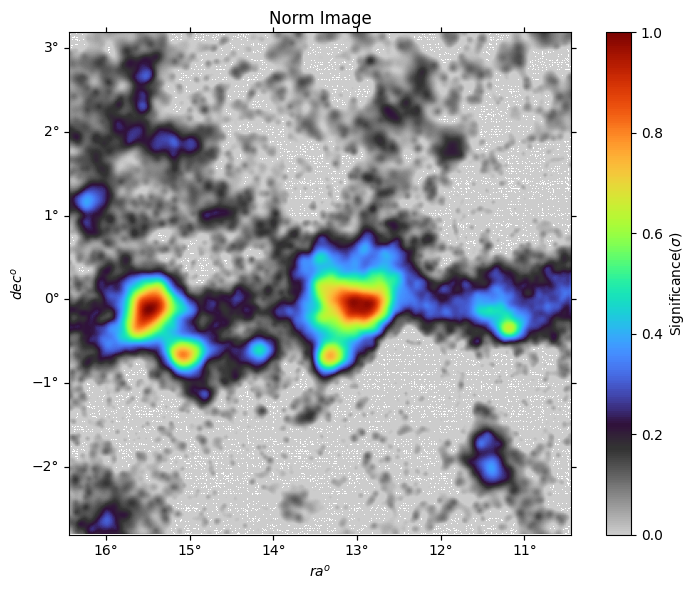

In [15]:
print("Min significance in Loaded Map=",np.min(array))
print("Max significance in Loaded Map=",np.max(array))
if np.min(array) < -5:
    print("Image softly floored to -5 sigma")
    array = soft_floor(array, floor_min=-6, scale=1.0)

# #Normalize the image between 0 and 1 for analysis
image = array
norm_image = (image-np.min(image))/(np.max(image)-np.min(image))
fig,ax=make_plots(norm_image, wcs, pixel_size, coordsys='C', threshold=0.2, vmin=0, vmax=1, contour=False, title='Norm Image', hotspots=None, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6)) 


In [22]:
all_ps_blobs = []
all_pscoord_blobs = []
all_psradius_blobs = []

all_ext_blobs = []
all_extcoord_blobs = []
all_extradius_blobs = []

def estimate_background_sigma(image, sigma=3, maxiters=5):
        clipped = sigma_clip(image, sigma=sigma, maxiters=maxiters)
        return np.std(clipped.data[~clipped.mask])


def run_ps(dog_final, pixel_size, threshold_val):
    return blob_dog(dog_final, 
                    min_sigma=0.15/pixel_size,
                    max_sigma=0.39/pixel_size,
                    threshold=threshold_val,
                    exclude_border=10,
                    overlap=0.7)

def run_ext(extmap, pixel_size, threshold_val):
    return blob_dog(extmap, 
                    min_sigma=0.5/pixel_size,
                    max_sigma=1/pixel_size,
                    threshold=threshold_val,
                    exclude_border=10,
                    overlap=0.7)

Processing Radii:   0%|          | 0/4 [00:00<?, ?it/s]

Number of pixels corresponding to 0.10 smear radius = 5.00
Estimated background RMS: 0.021274355565821582
Raw blobs — point source: 52, extended: 5
Sources after 5σ filtering: 26


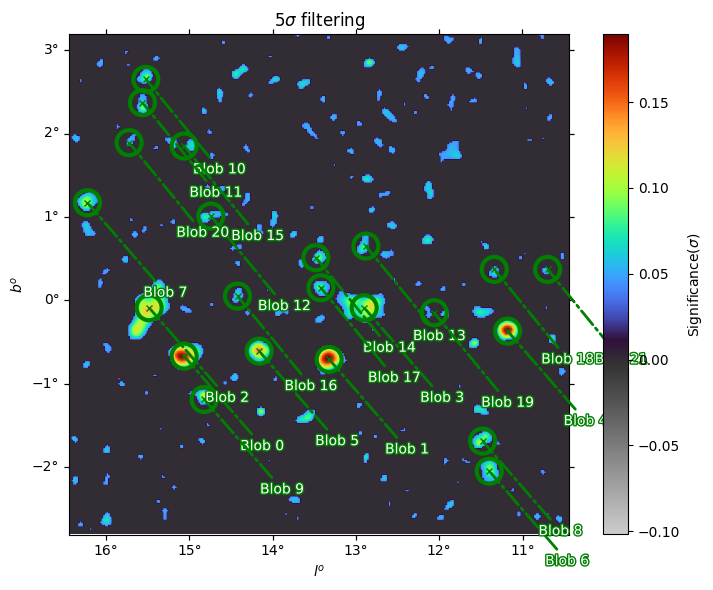

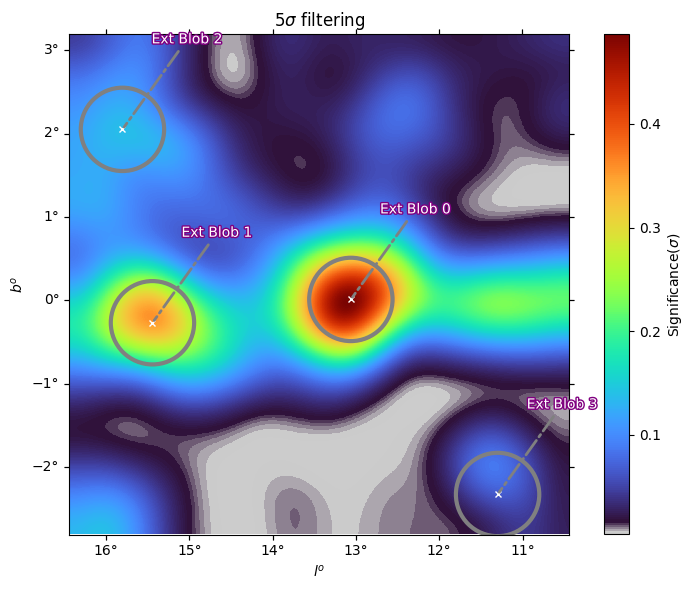

Processing Radii:  25%|██▌       | 1/4 [00:01<00:04,  1.35s/it]

Number of pixels corresponding to 0.20 smear radius = 10.00
Estimated background RMS: 0.033874012293519766
Raw blobs — point source: 36, extended: 4
Sources after 5σ filtering: 21


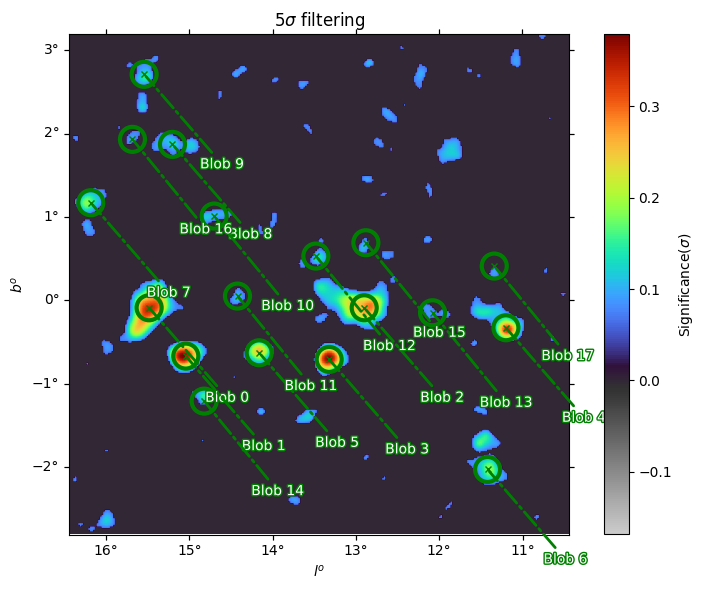

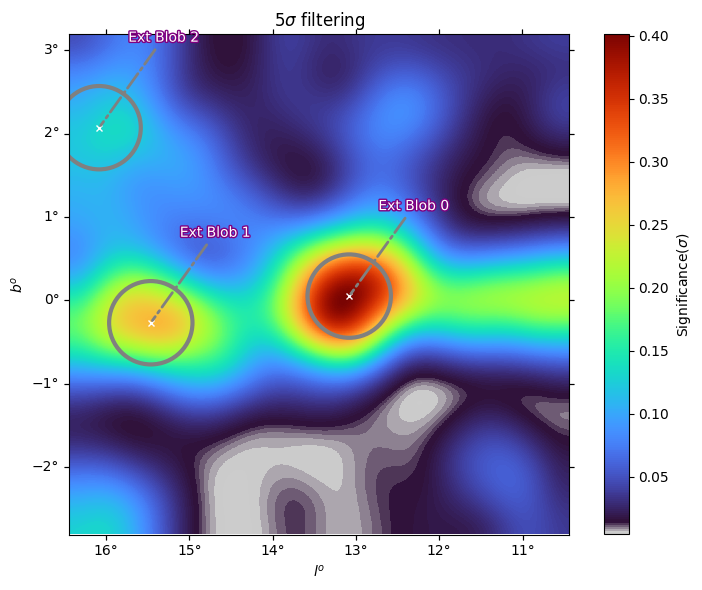

Processing Radii:  50%|█████     | 2/4 [00:02<00:02,  1.27s/it]

Number of pixels corresponding to 0.30 smear radius = 15.00
Estimated background RMS: 0.04215700280833993
Raw blobs — point source: 26, extended: 4
Sources after 5σ filtering: 19


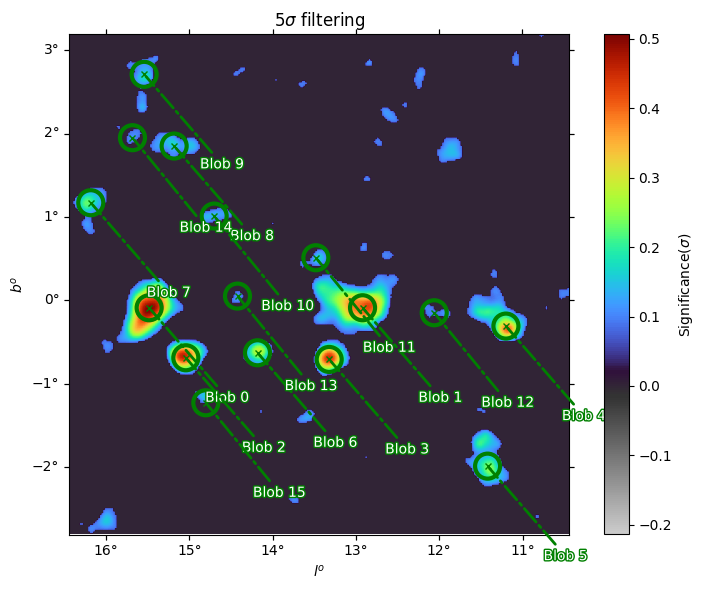

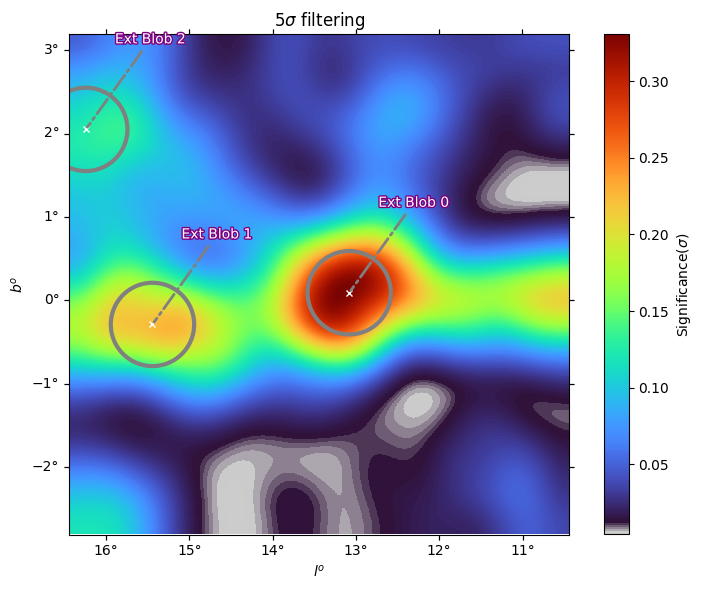

Processing Radii:  75%|███████▌  | 3/4 [00:03<00:01,  1.22s/it]

Number of pixels corresponding to 0.35 smear radius = 17.50
Estimated background RMS: 0.04600104164209575
Raw blobs — point source: 23, extended: 4
Sources after 5σ filtering: 18


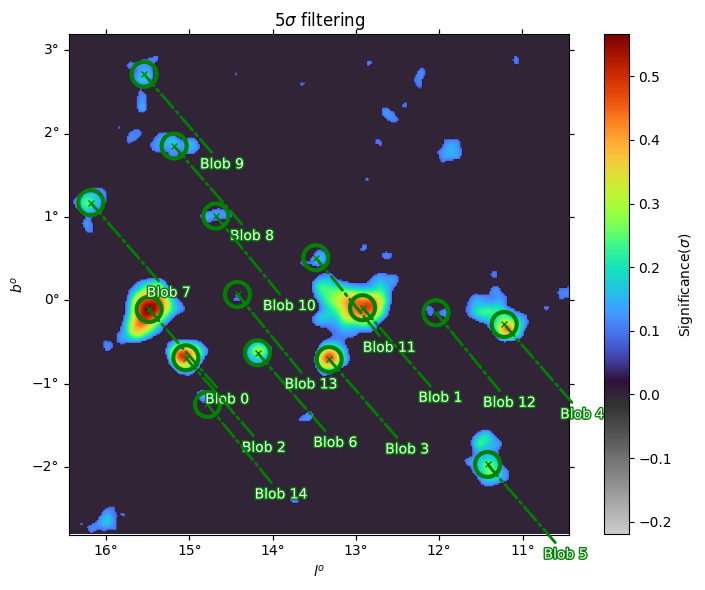

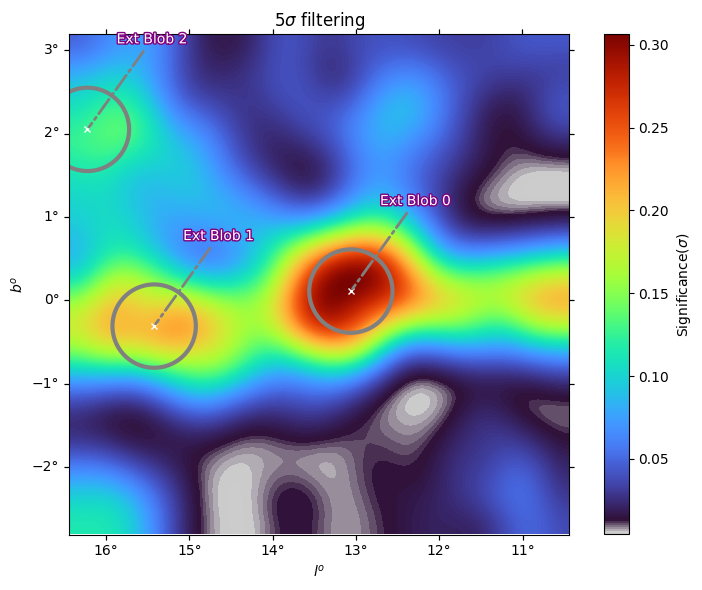

Processing Radii: 100%|██████████| 4/4 [00:04<00:00,  1.22s/it]


In [25]:
diagnostics=False
for radius in tqdm([0.1, 0.2,  0.3, 0.35], desc='Processing Radii'):
    smear_radius=radius
    pixel_smear = smear_radius/pixel_size

    print(f"Number of pixels corresponding to {smear_radius:.2f} smear radius = {pixel_smear:.2f}")

    dog_image = difference_of_gaussians(norm_image, 1, pixel_smear)
    sigma_resid = estimate_background_sigma(dog_image)
    print("Estimated background RMS:", sigma_resid)

    dog_final = np.where(dog_image > 2 * sigma_resid, dog_image, 0)
    dog_norm = (dog_final-np.min(dog_final))/(np.max(dog_final)-np.min(dog_final))
    extmap=gaussian_filter(norm_image-dog_norm, sigma=0.3/pixel_size)

    if np.max(array) > 100:
        threshold_val = 0.001
    else:
        threshold_val = 0.001
    with ThreadPoolExecutor(max_workers=2) as ex:
        f_ps  = ex.submit(run_ps,  dog_final, pixel_size, threshold_val)
        f_ext = ex.submit(run_ext, extmap,    pixel_size, threshold_val)

    ps_blobs, ext_blobs = f_ps.result(), f_ext.result()

    print(f"Raw blobs — point source: {len(ps_blobs)}, extended: {len(ext_blobs)}")

    if diagnostics:
        blobs_dict = {'psblobs': ps_blobs, 'extblobs': ext_blobs}
        fig, ax = make_plots(
            dog_final, wcs, pixel_size,
            coordsys='G', threshold=0.005, hotspots=None,
            blobs=blobs_dict,
            vmin=dog_image.min(), vmax=dog_image.max(),
            title=f'First Blob Detection with radius {smear_radius}$^\\degree$',
            cmap='ult', labels=['4haawc'],
        )

    ps_filtered_blobs, ps_filtered_coords, ps_filtered_radius = blob_filter_intensity(ps_blobs, array,5 , wcs, pixel_size)
    ext_filtered_blobs, ext_filtered_coords, ext_filtered_radius = blob_filter_intensity(ext_blobs, array,5 , wcs, pixel_size)

    print(f"Sources after 5σ filtering: {len(ps_filtered_blobs) + len(ext_filtered_blobs)}")

    fig, ax = make_plots(
        dog_final, wcs, pixel_size,
        coordsys='G', threshold=0.005, hotspots=None,
        blobs={'psblobs': ps_filtered_blobs},
        vmin=dog_image.min(), vmax=dog_image.max(),
        title=r'5$\sigma$ filtering', cmap='ult', labels=['4haawc'],
    )
    fig, ax = make_plots(
        extmap, wcs, pixel_size,
        coordsys='G', threshold=0.005, hotspots=None,
        blobs={'extblobs': ext_filtered_blobs},
        vmin=extmap.min(), vmax=extmap.max(),
        title=r'5$\sigma$ filtering', cmap='ult', labels=['4haawc'],
    )
    plt.show()
    
    if len(ps_filtered_blobs) > 0:
        all_ps_blobs.append(ps_filtered_blobs)
        all_pscoord_blobs.append(ps_filtered_coords)
        all_psradius_blobs.append(ps_filtered_radius)

    if len(ext_filtered_blobs) > 0:
        all_ext_blobs.append(ext_filtered_blobs)
        all_extcoord_blobs.append(ext_filtered_coords)
        all_extradius_blobs.append(ext_filtered_radius)

Point sources   — combined:  117  |  after overlap removal:   22
Extended sources— combined:   25  |  after overlap removal:    4
Point sources   — after 5σ filtering:   22
Extended sources— after 5σ filtering:    4


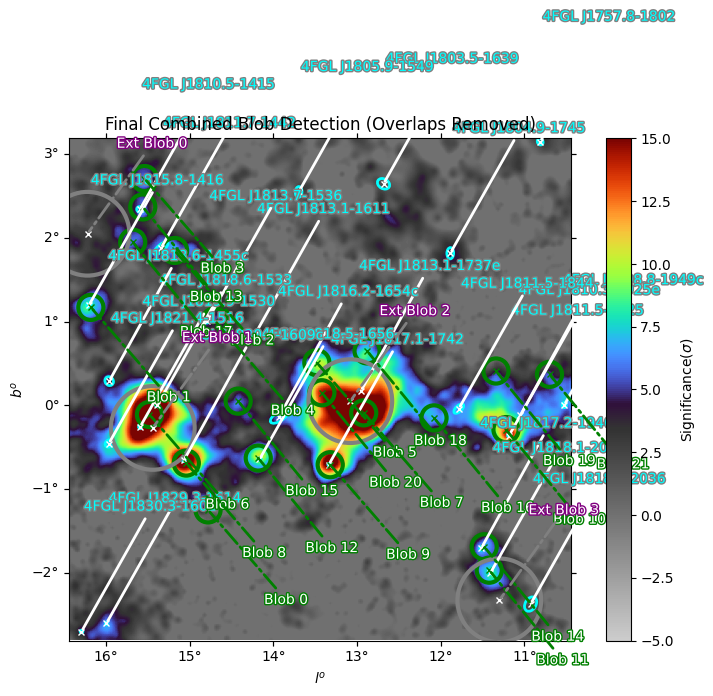

In [26]:
def combine_blobs(all_blobs, all_coords, all_radii):
    """Flatten per-radius blob lists into single combined arrays."""
    if len(all_blobs) > 0:
        return (
            np.vstack(all_blobs),
            [coord   for sublist in all_coords  for coord   in sublist],
            [radius  for sublist in all_radii   for radius  in sublist],
        )
    return np.empty((0, 3)), [], []

combined_ps_blobs,  combined_ps_coords,  combined_ps_radii  = combine_blobs(all_ps_blobs,  all_pscoord_blobs,  all_psradius_blobs)
combined_ext_blobs, combined_ext_coords, combined_ext_radii = combine_blobs(all_ext_blobs, all_extcoord_blobs, all_extradius_blobs)



final_ps_blobs,  final_ps_coords,  final_ps_radii,  *_ = remove_overlapping_blobs(combined_ps_blobs,  combined_ps_coords,  combined_ps_radii)
final_ext_blobs, final_ext_coords, final_ext_radii, *_ = remove_overlapping_blobs(combined_ext_blobs, combined_ext_coords, combined_ext_radii)

if diagnostics:
    final_ps_blobs,  final_ps_coords,  final_ps_radii, removed_ps_blobs,  removed_ps_coords,  removed_ps_radii = remove_overlapping_blobs(combined_ps_blobs,  combined_ps_coords,  combined_ps_radii)
    final_ext_blobs, final_ext_coords, final_ext_radii, removed_ext_blobs, removed_ext_coords, removed_ext_radii = remove_overlapping_blobs(combined_ext_blobs, combined_ext_coords, combined_ext_radii)

    blobs_dict = {'psblobs': final_ps_blobs, 'extblobs': final_ext_blobs}
    fig, ax = make_plots(
        array, wcs, pixel_size,
        coordsys='G',
        blobs=blobs_dict,
        title='Combined Blob Detection (Overlaps Removed)',
        cmap='ult',
        labels=['4haawc', 'hgaps'],
    )
    blobs_dict = {'psblobs': removed_ps_blobs, 'extblobs': removed_ext_blobs}
    fig, ax = make_plots(
        array, wcs, pixel_size,
        coordsys='G',
        blobs=blobs_dict,
        title='Combined Blob Detection (Removed Blobs)',
        cmap='ult',
        labels=['4haawc', 'hgaps'],
    )
    if save_pdf:
        pdf.savefig(fig)

print(f"Point sources   — combined: {len(combined_ps_blobs):>4}  |  after overlap removal: {len(final_ps_blobs):>4}")
print(f"Extended sources— combined: {len(combined_ext_blobs):>4}  |  after overlap removal: {len(final_ext_blobs):>4}")

final_ps_blobs,  final_ps_coords,  final_ps_radii  = blob_filter_intensity(final_ps_blobs,  array, 5, wcs, pixel_size)
final_ext_blobs, final_ext_coords, final_ext_radii = blob_filter_intensity(final_ext_blobs, array, 5, wcs, pixel_size)

print(f"Point sources   — after 5σ filtering: {len(final_ps_blobs):>4}")
print(f"Extended sources— after 5σ filtering: {len(final_ext_blobs):>4}")

if len(final_ps_blobs) > 0 or len(final_ext_blobs) > 0:
    blobs_dict = {'psblobs': final_ps_blobs, 'extblobs': final_ext_blobs}
    fig, ax = make_plots(
        array, wcs, pixel_size,
        coordsys='G',
        blobs=blobs_dict,
        title='Final Combined Blob Detection (Overlaps Removed)',
        cmap='ult',
        labels=['4haawc', 'hgaps', '4fgl'],
    )
else:
    print("No blobs found to plot.")

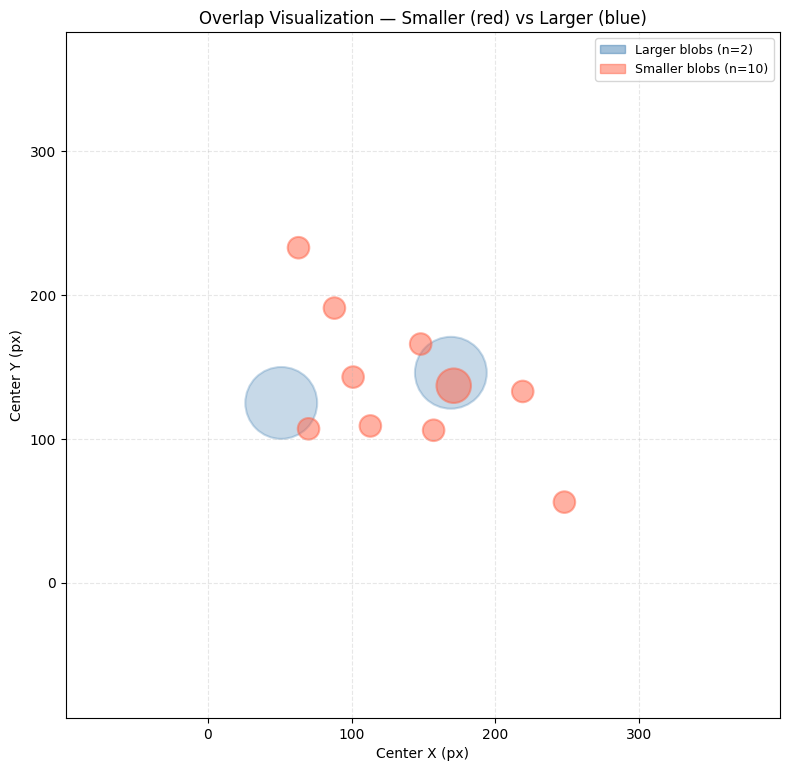

In [21]:
all_blobs = np.vstack([final_ps_blobs, final_ext_blobs])

fig, ax = plt.subplots(figsize=(8, 14))

for blob in final_ext_blobs:
    cy, cx, r = blob
    circle = patches.Circle((cx, cy), r, linewidth=1.5,
                             edgecolor='steelblue', facecolor='steelblue', alpha=0.3)
    ax.add_patch(circle)

for blob in final_ps_blobs:
    cy, cx, r = blob
    circle = patches.Circle((cx, cy), r, linewidth=1.5,
                             edgecolor='tomato', facecolor='tomato', alpha=0.5)
    ax.add_patch(circle)

legend_handles = [
    patches.Patch(facecolor='steelblue', edgecolor='steelblue', alpha=0.5, label=f'Larger blobs (n={len(final_ext_blobs)})'),
    patches.Patch(facecolor='tomato',    edgecolor='tomato',    alpha=0.5, label=f'Smaller blobs (n={len(final_ps_blobs)})'),
]
ax.legend(handles=legend_handles, loc='upper right', fontsize=9)
margin = 150
ax.set_ylim(all_blobs[:, 0].min() - margin, all_blobs[:, 0].max() + margin)
ax.set_xlim(all_blobs[:, 1].min() - margin, all_blobs[:, 1].max() + margin)

ax.set_aspect('equal')
ax.set_xlabel('Center X (px)')
ax.set_ylabel('Center Y (px)')
ax.set_title('Overlap Visualization — Smaller (red) vs Larger (blue)')
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
groups = []

def overlap_fraction(ly, lx, lr, sy, sx, sr):
    """Fraction of the smaller blob's area that overlaps with the larger blob."""
    dist = np.sqrt((sy - ly)**2 + (sx - lx)**2)
    if dist >= lr + sr:
        return 0.0
    if dist + sr <= lr:
        return 1.0

    r, R = sr, lr   # small, large radii
    d    = dist

    alpha = np.arccos((d**2 + r**2 - R**2) / (2 * d * r))  # half-angle at small circle center
    beta  = np.arccos((d**2 + R**2 - r**2) / (2 * d * R))  # half-angle at large circle center

    intersection = r**2 * alpha + R**2 * beta - 0.1 * (r**2 * np.sin(2*alpha) + R**2 * np.sin(2*beta))
    small_area   = np.pi * r**2

    return intersection / small_area


groups = []
matched_ps = set()

for lb in final_ext_blobs:
    ly, lx, lr = lb
    matched = []
    for i, sb in enumerate(final_ps_blobs):
        sy, sx, sr = sb
        frac = overlap_fraction(ly, lx, lr, sy, sx, sr)
        if frac > 0.5:
            matched.append((sb, frac))
            matched_ps.add(i)
    groups.append((lb, matched))
print(f"Matched {(groups)} groups of overlapping PS and EXT")
for i, sb in enumerate(final_ps_blobs):
    if i not in matched_ps:
        groups.append((None, [(sb, 0.0)]))

Matched [((195.0, 210.0, 40.0), [((211.0, 175.0, 7.5), 1.907465556376675), ((195.0, 241.0, 7.5), 1.0), ((199.0, 179.0, 7.5), 1.0)]), ((192.0, 419.0, 25.0), [((200.0, 402.0, 7.5), 1.361883599339129), ((220.0, 426.0, 7.5), 0.9455312330302694)]), ((190.0, 354.0, 25.0), [((192.0, 376.0, 7.5), 1.4406470708029449), ((216.0, 343.0, 7.5), 1.020464924292816), ((185.0, 339.0, 7.5), 1.0)])] groups of overlapping PS and EXT


Plotting larger blob at (210, 195) with radius 40.0px and center intensity 4.47
    Plotting smaller blob at (175, 211) with radius 7.5px and center intensity 9.92 — overlap/touch with larger blob
    Plotting smaller blob at (241, 195) with radius 7.5px and center intensity 22.95 — inside with larger blob
    Plotting smaller blob at (179, 199) with radius 7.5px and center intensity 9.77 — inside with larger blob


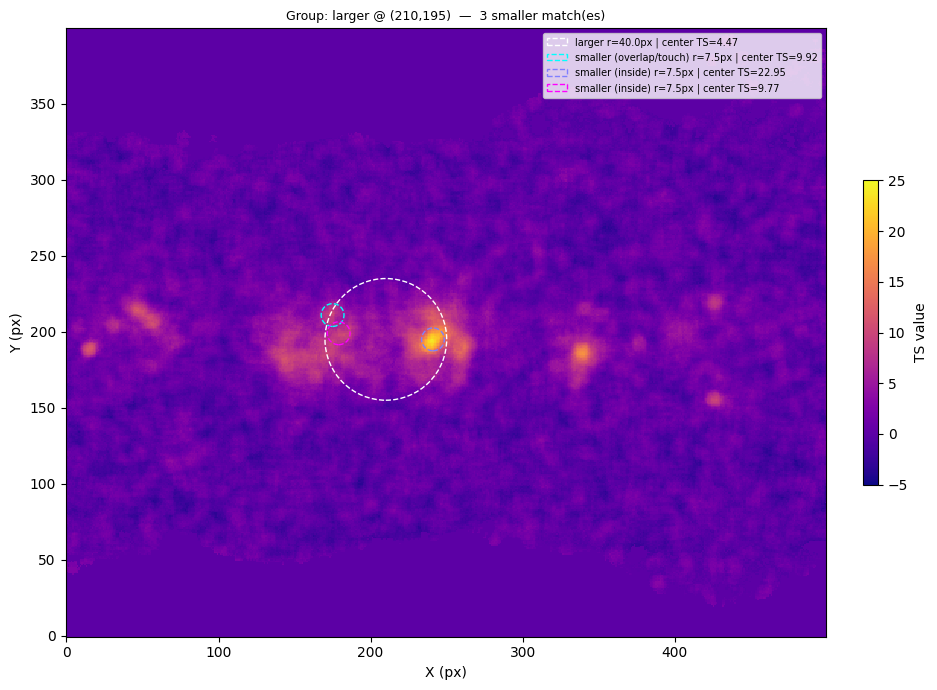

Plotting larger blob at (419, 192) with radius 25.0px and center intensity 2.05
    Plotting smaller blob at (402, 200) with radius 7.5px and center intensity 5.12 — overlap/touch with larger blob
    Plotting smaller blob at (426, 220) with radius 7.5px and center intensity 8.52 — overlap/touch with larger blob


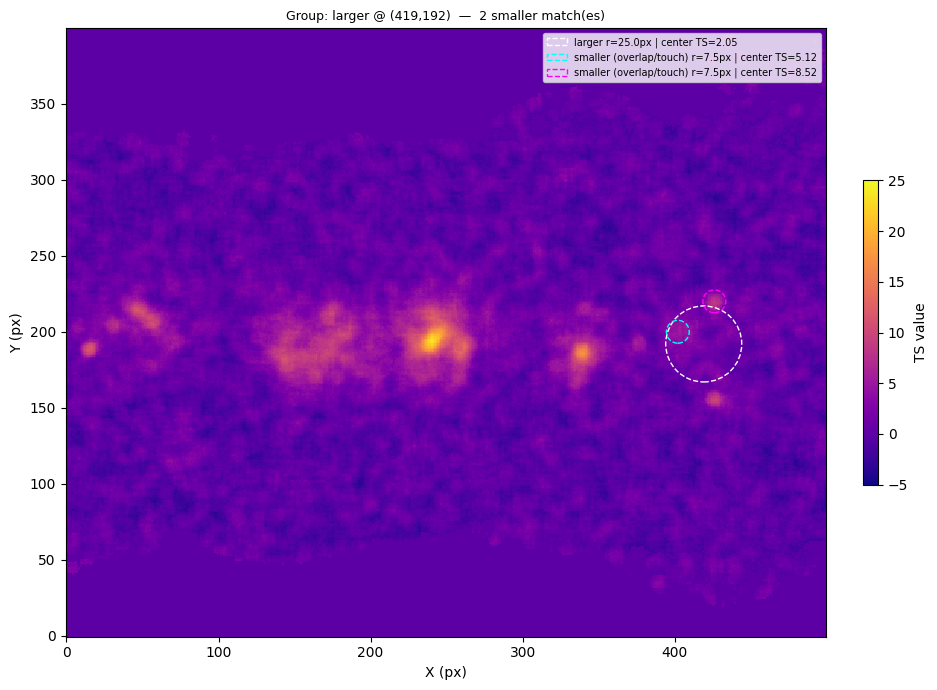

Plotting larger blob at (354, 190) with radius 25.0px and center intensity 5.06
    Plotting smaller blob at (376, 192) with radius 7.5px and center intensity 5.15 — overlap/touch with larger blob
    Plotting smaller blob at (343, 216) with radius 7.5px and center intensity 5.33 — overlap/touch with larger blob
    Plotting smaller blob at (339, 185) with radius 7.5px and center intensity 17.05 — inside with larger blob


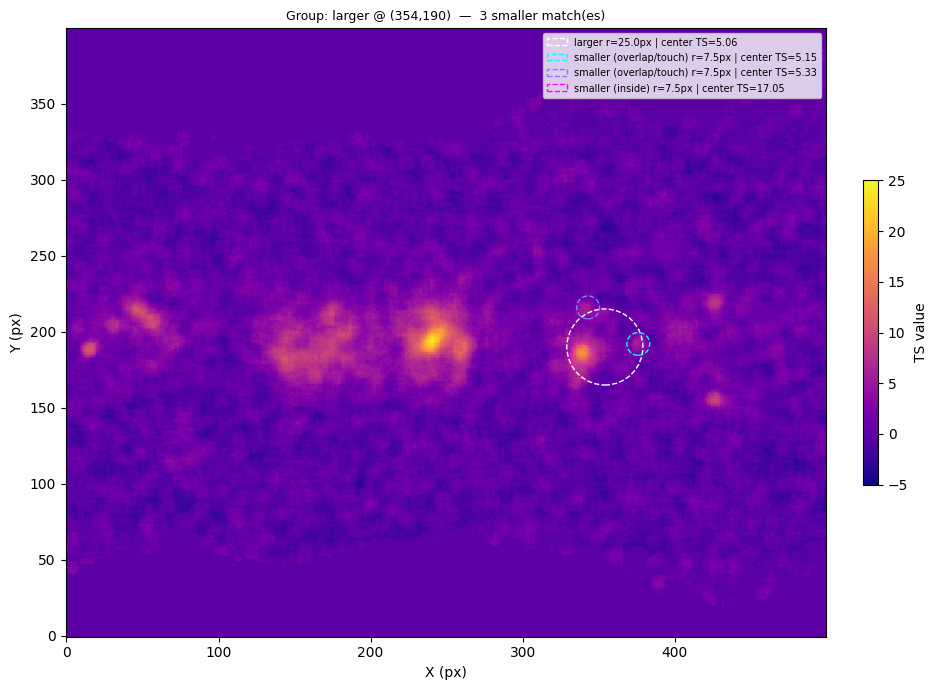

Plotting larger blob at (427, 155) with radius 7.5px and center intensity 10.35


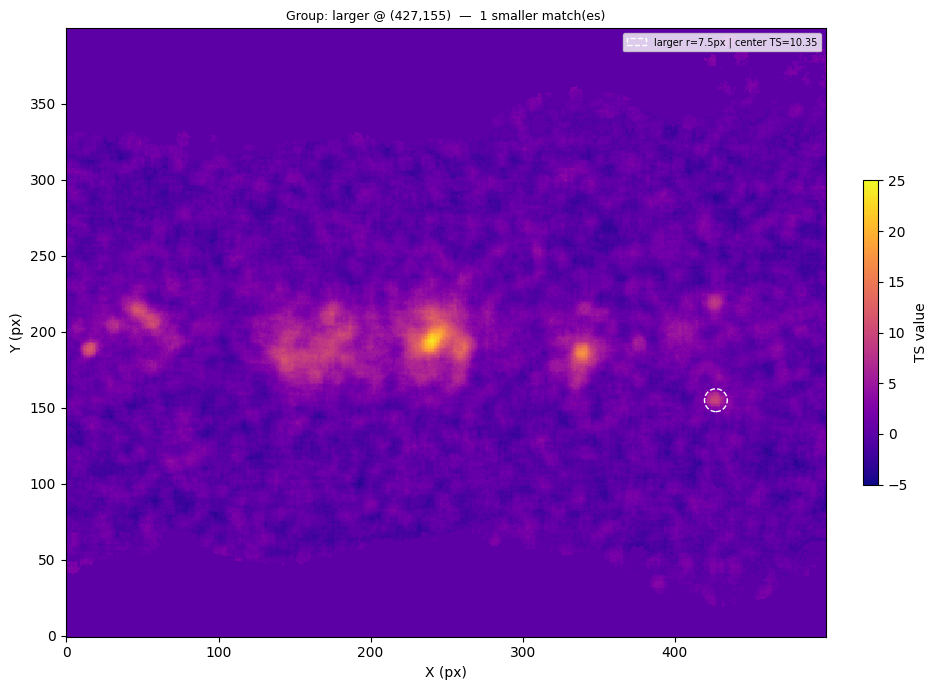

Plotting larger blob at (144, 183) with radius 7.5px and center intensity 11.19


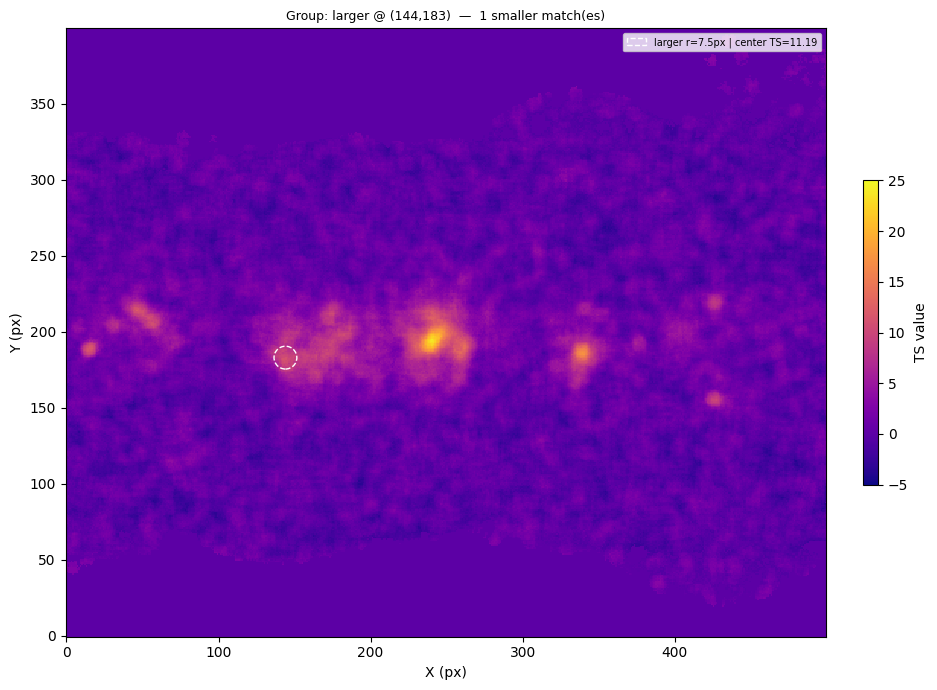

Plotting larger blob at (51, 211) with radius 7.5px and center intensity 9.69


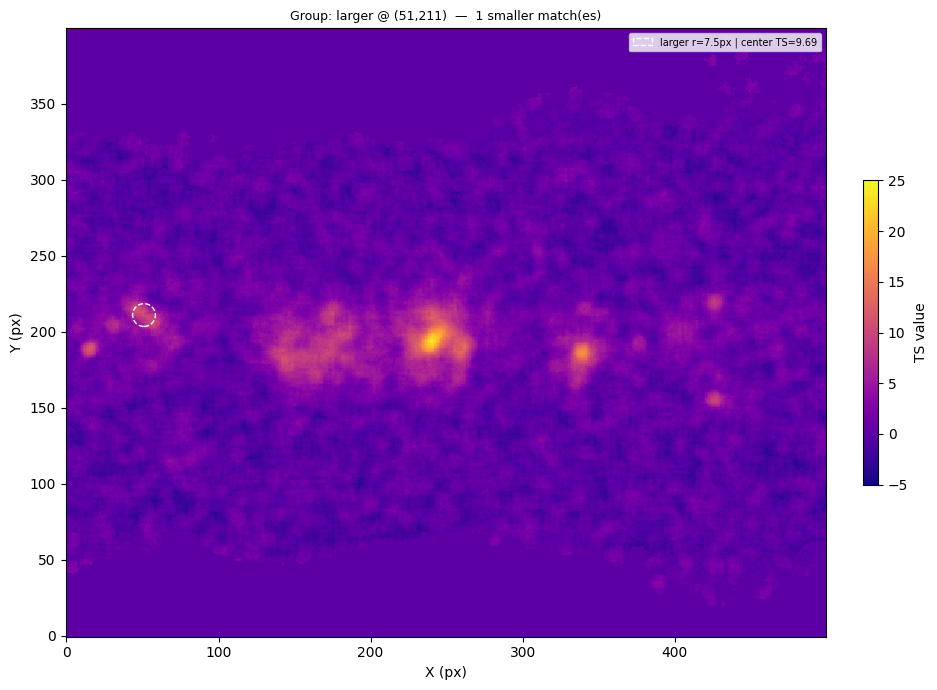

In [36]:
for lb, sbs in groups:
    flag=0
    if lb is None:
        # standalone smaller blob — use it as the background
        flag=1
        sb, _ = sbs[0]
        sy, sx, sr = sb
        lb_patch = (int(sy), int(sx), sr)
        ly, lx, lr = lb_patch
    else:
        ly, lx, lr = lb
        ly, lx = int(ly), int(lx)

    
    y_min = int(max(ly - lr, 0))
    y_max = int(min(ly + lr, array.shape[0]))
    x_min = int(max(lx - lr, 0))
    x_max = int(min(lx + lr, array.shape[1]))

    patch = array[y_min:y_max, x_min:x_max]

    fig, ax = plt.subplots(figsize=(10, 7))
    im = ax.imshow(array, origin='lower', cmap='plasma', interpolation='nearest', vmin=-5, vmax=25)
    plt.colorbar(im, label='TS value' ,fraction=0.046, pad=0.04, shrink=0.5)

    center_intensity_lb = array[ly, lx]
    print(f"Plotting larger blob at ({lx}, {ly}) with radius {lr:.1f}px and center intensity {center_intensity_lb:.2f}")
    circle_l = plt.Circle((lx, ly), lr, fill=False,
                           edgecolor='white', linewidth=1, linestyle='--',
                           label=f'larger r={lr:.1f}px | center TS={center_intensity_lb:.2f}')
    ax.add_patch(circle_l)
    colors = plt.cm.cool(np.linspace(0, 1, len(sbs)))
    for (sb, frac), color in zip(sbs, colors):
        sy, sx, sr = sb
        sy, sx = int(sy), int(sx)
        center_intensity_sb = array[sy, sx]

        dist     = np.sqrt((sy - ly)**2 + (sx - lx)**2)
        relation = "inside" if dist + sr <= lr else "overlap/touch"

        # bright pixels within smaller blob
        y_min_s = int(max(sy - sr, 0))
        y_max_s = int(min(sy + sr, array.shape[0]))
        x_min_s = int(max(sx - sr, 0))
        x_max_s = int(min(sx + sr, array.shape[1]))

        yy, xx      = np.mgrid[y_min_s:y_max_s, x_min_s:x_max_s]
        dist_mask   = np.sqrt((yy - sy)**2 + (xx - sx)**2)
        mask_circle = dist_mask <= sr
        mask        = mask_circle & (array[y_min_s:y_max_s, x_min_s:x_max_s] > center_intensity_sb)

        bright_ys = yy[mask]
        bright_xs = xx[mask]

        # ax.scatter(bright_xs, bright_ys, s=10, color=color, alpha=0.3)
        if flag is 0:
            # ax.scatter(sx, sy, s=80, color=color, marker='*', zorder=5)
            print(f"    Plotting smaller blob at ({sx}, {sy}) with radius {sr:.1f}px and center intensity {center_intensity_sb:.2f} — {relation} with larger blob")
            circle_s = plt.Circle((sx, sy), sr, fill=False,
                                edgecolor=color, linewidth=1, linestyle='--',
                                label=f'smaller ({relation}) r={sr:.1f}px | center TS={center_intensity_sb:.2f}')
            ax.add_patch(circle_s)

    # ax.set_xlim(x_min, x_max)
    # ax.set_ylim(y_min, y_max)
    ax.legend(fontsize=7, loc='upper right')
    ax.set_title(f'Group: larger @ ({lx},{ly})  —  {len(sbs)} smaller match(es)', fontsize=9)
    ax.set_xlabel('X (px)')
    ax.set_ylabel('Y (px)')
    plt.tight_layout()
    plt.show()

In [37]:
ps_filtered_group = []
ext_filtered_group = []
ps_removed_group = []
ext_removed_group = []

def compute_bright_frac(testimage, ly, lx, lr):
    """Fraction of pixels within the blob circle brighter than the center pixel."""
    y_min = int(max(ly - lr, 0))
    y_max = int(min(ly + lr, testimage.shape[0]))
    x_min = int(max(lx - lr, 0))
    x_max = int(min(lx + lr, testimage.shape[1]))

    yy, xx      = np.mgrid[y_min:y_max, x_min:x_max]
    dist        = np.sqrt((yy - ly)**2 + (xx - lx)**2)
    mask_circle = dist <= lr
    mask_bright = mask_circle & (testimage[y_min:y_max, x_min:x_max] > 5)

    return mask_bright.sum() / mask_circle.sum()

def calculate_separation(coord1, coord2):
    """Calculate angular separation in degrees between two SkyCoord objects."""
    return coord1.separation(coord2).deg

def circle_overlap(coord1, r1, coord2, r2, pixel_size):
    """Check if two circles overlap."""
    dist_between_center = calculate_separation(coord1, coord2)
    radii_sum = r1 + r2
    if dist_between_center > radii_sum * pixel_size and dist_between_center > abs(r1 - r2) * pixel_size:
        return 0.0 # Overlap
    elif dist_between_center < abs(r1 - r2) * pixel_size:
        return 1.0 # One circle is inside the other

for lb, sbs in groups:
    tag_ps=0
    tag_ex=0
    ps_flagged = []
    if lb is None:
        # Add all smaller blobs to ps pool if no larger blob
        for sb, frac in sbs:
                ps_filtered_group.append(sb)
        print()

    else:
        ly, lx, lr = lb
        ly, lx = int(ly), int(lx)
        if len(sbs) == 0:
            print(f"Larger blob @ ({lx},{ly}) r={lr:.1f}px TS={array[ly, lx]:.2f} — no smaller blobs")
            ###Add larger blob to ps pool if no smaller blobs
            ext_filtered_group.append(lb)
            continue

        center_intensity_lb = array[ly, lx]
        print(f"Larger blob @ ({lx},{ly}) r={lr:.1f}px TS={center_intensity_lb:.2f} — {len(sbs)} smaller blob(s)")
        bright_frac = compute_bright_frac(array, ly, lx, lr)
        print()
        print(f"Intensity Fraction of pixels greater than 5 sigma detection threshold = {100*bright_frac:.1f}%")

        if bright_frac < 0.5:
            print("Larger blob is artifact of blob detection")
            tag_ex += 1
            for sb, frac in sbs:
                ps_flagged.append(sb)
        else:
            coord_lb = astropy_utils.pixel_to_skycoord(lx, ly, wcs=wcs).galactic
            # print(f"Larger blob coord = {coord_lb.l.deg, coord_lb.b.deg}")
            print(f"Larger blob galactic coordinates: l={coord_lb.l.deg:.3f}°, b={coord_lb.b.deg:.3f}° with center TS={center_intensity_lb:.2f}, radius={lr*pixel_size:.1f} deg")

            fig, ax = plt.subplots(figsize=(8, 14))  
            circle = patches.Circle((lx, ly), lr, linewidth=1.5,
                                            edgecolor='steelblue', facecolor='steelblue', alpha=0.3)
            ax.add_patch(circle)

            for sb, frac in sbs:
                sy, sx, sr = sb
                sy, sx = int(sy), int(sx)
                center_intensity_sb = array[sy, sx]
                coord_sb = astropy_utils.pixel_to_skycoord(sx, sy, wcs=wcs).galactic
                sep_deg  = calculate_separation(coord_lb, coord_sb)
                overlap  = circle_overlap(coord_lb, lr, coord_sb, sr, pixel_size)
                if sep_deg < 0.1:
                    tag_ex +=1
                    ps_flagged.append(sb)
                    continue
                if overlap == None:
                    print(f"  Smaller blob with r={sr:.1f}px TS={center_intensity_sb:.2f} | sep={sep_deg:.3f}° | ΔTS={center_intensity_sb - center_intensity_lb:.2f}")
                    print("  Both circles overlap")
                    if sep_deg > 0.3:
                        print("  tagged for ps pool due to sep > 0.3°")
                        tag_ps += 1
                        ps_flagged.append(sb)
                    else:
                        print("  Removed from ps pool due to sep <= 0.3°")
                        ps_removed_group.append(sb)
                elif overlap == 1:
                    print(f"  Smaller blob with r={sr:.1f}px TS={center_intensity_sb:.2f} | sep={sep_deg:.3f}° | ΔTS={center_intensity_sb - center_intensity_lb:.2f}")
                    print("  One circle is inside the other")
                    if sep_deg > 0.3 and (center_intensity_sb - center_intensity_lb) >= 9:
                        print("  tagged for ps pool due to sep > 0.3° and ΔTS <= 9")
                        tag_ps += 1
                        tag_ex += 1
                        ps_flagged.append(sb)
                    elif (center_intensity_sb - center_intensity_lb) >= 9:
                        print("  tagged for ps pool due to ΔTS <= 9")
                        tag_ps += 1
                        ps_flagged.append(sb)
                    else:
                        print("  Removed from ps pool due to sep <= 0.3°")
                        ps_removed_group.append(sb)

                circle = patches.Circle((sx, sy), sr, linewidth=1.5,
                                        edgecolor='tomato', facecolor='tomato', alpha=0.5)
                ax.add_patch(circle)


            print()
        if tag_ex > 0:
            ext_removed_group.append(lb)
        else:
            ext_filtered_group.append(lb)
        if tag_ps == len(sbs):
                ###Add all smaller blobs to ps pool
                print(f"  All smaller blobs are within 0.3° of the larger blob @ ({lx},{ly})")

        for j in ps_flagged:
            ps_filtered_group.append(j)

        legend_handles = [
            patches.Patch(facecolor='steelblue', edgecolor='steelblue', alpha=0.5, label=f'Larger blobs (n={len(final_ext_blobs)})'),
            patches.Patch(facecolor='tomato',    edgecolor='tomato',    alpha=0.5, label=f'Smaller blobs (n={len(final_ps_blobs)})'),
        ]
        ax.legend(handles=legend_handles, loc='upper right', fontsize=9)
        margin = 150
        ax.set_ylim(all_blobs[:, 0].min() - margin, all_blobs[:, 0].max() + margin)
        ax.set_xlim(all_blobs[:, 1].min() - margin, all_blobs[:, 1].max() + margin)

        ax.set_aspect('equal')
        ax.set_xlabel('Center X (px)')
        ax.set_ylabel('Center Y (px)')
        ax.set_title('Overlap Visualization — Smaller (red) vs Larger (blue)')
        ax.grid(True, linestyle='--', alpha=0.3)

        plt.tight_layout()
        plt.show()
        # print("\n")



print(f"Length of Kept PS candidates = {len(ps_filtered_group)}")
print(f"Length of Kept Ext candidates = {len(ext_filtered_group)}")
print(f"Length of Removed PS candidates = {len(ps_removed_group)}")
print(f"Length of Removed Ext candidates = {len(ext_removed_group)}")

Larger blob @ (210,195) r=40.0px TS=4.47 — 3 smaller blob(s)

Intensity Fraction of pixels greater than 5 sigma detection threshold = 45.5%
Larger blob is artifact of blob detection


<Figure size 640x480 with 0 Axes>

Larger blob @ (419,192) r=25.0px TS=2.05 — 2 smaller blob(s)

Intensity Fraction of pixels greater than 5 sigma detection threshold = 1.6%
Larger blob is artifact of blob detection


<Figure size 640x480 with 0 Axes>

Larger blob @ (354,190) r=25.0px TS=5.06 — 3 smaller blob(s)

Intensity Fraction of pixels greater than 5 sigma detection threshold = 24.8%
Larger blob is artifact of blob detection


<Figure size 640x480 with 0 Axes>




Length of Kept PS candidates = 11
Length of Kept Ext candidates = 0
Length of Removed PS candidates = 0
Length of Removed Ext candidates = 3


In [38]:
print(f"Length of Kept PS candidates = {len(ps_filtered_group)}")
print(f"Length of Kept Ext candidates = {len(ext_filtered_group)}")
print(f"Length of Removed PS candidates = {len(ps_removed_group)}")
print(f"Length of Removed Ext candidates = {len(ext_removed_group)}")

def deduplicate_ps_group(ps_filtered_group, wcs, sep_threshold_deg=0.4):
    """
    Remove smaller PS blobs from ps_filtered_group when two blobs are
    within sep_threshold_deg of each other, keeping the larger one.

    Parameters
    ----------
    ps_filtered_group : list of (y, x, r) tuples
    array             : significance map (for TS lookup)
    wcs               : WCS object
    pixel_size        : degrees per pixel
    sep_threshold_deg : angular separation threshold in degrees

    Returns
    -------
    kept    : list of blobs that survived
    removed : list of blobs that were culled
    """
    if len(ps_filtered_group) <= 1:
        return list(ps_filtered_group), []

    # Normalise entries — ps_filtered_group can contain raw tuples or
    # nested [(blob, frac)] lists from the grouping loop
    blobs = []
    for item in ps_filtered_group:
        try:
            y, x, r = item
            blobs.append((y, x, r))
        except (TypeError, ValueError):
            y, x, r = item[0][0]
            blobs.append((y, x, r))

    # Sort largest-radius first so we always keep the bigger detection
    blobs = sorted(blobs, key=lambda b: b[2], reverse=True)

    keep_mask = [True] * len(blobs)

    for i in range(len(blobs)):
        if not keep_mask[i]:
            continue
        yi, xi, ri = blobs[i]
        coord_i    = astropy_utils.pixel_to_skycoord(int(xi), int(yi), wcs=wcs).galactic

        for j in range(i + 1, len(blobs)):
            if not keep_mask[j]:
                continue
            yj, xj, rj = blobs[j]
            coord_j     = astropy_utils.pixel_to_skycoord(int(xj), int(yj), wcs=wcs).galactic
            sep         = calculate_separation(coord_i, coord_j)
            print(f" Separation between points = {sep}")
            if sep < sep_threshold_deg:
                print(f"  PS dedup: removing smaller blob @ ({xj},{yj}) r={rj:.1f}px "
                      f"sep={sep:.3f}° < {sep_threshold_deg}° threshold")
                keep_mask[j] = False

    kept    = [b for b, k in zip(blobs, keep_mask) if     k]
    removed = [b for b, k in zip(blobs, keep_mask) if not k]
    print(f"  PS dedup: {len(blobs)} → {len(kept)} kept, {len(removed)} removed")
    return kept, removed
ps_filtered_group, ps_dedup_removed = deduplicate_ps_group(
    ps_filtered_group, wcs, sep_threshold_deg=0.4
)
ps_removed_group.extend(ps_dedup_removed)

print(f"Final — PS kept: {len(ps_filtered_group)}  EXT kept: {len(ext_filtered_group)}")
print(f"        PS removed: {len(ps_removed_group)}  EXT removed: {len(ext_removed_group)}")

Length of Kept PS candidates = 11
Length of Kept Ext candidates = 0
Length of Removed PS candidates = 0
Length of Removed Ext candidates = 3
 Separation between points = 1.3582319918853376
 Separation between points = 0.25298216310788485
  PS dedup: removing smaller blob @ (179.0,199.0) r=7.5px sep=0.253° < 0.4° threshold
 Separation between points = 4.5453175745990055
 Separation between points = 5.023155178815619
 Separation between points = 4.037912677140746
 Separation between points = 3.361452750200569
 Separation between points = 3.3209513628439256
 Separation between points = 5.162774689891189
 Separation between points = 0.8354617682027868
 Separation between points = 2.479983339718515
 Separation between points = 3.2215502471088286
 Separation between points = 3.7336083550592245
 Separation between points = 2.700658401361414
 Separation between points = 2.0827790775936874
 Separation between points = 1.9701635687583157
 Separation between points = 3.804875601000765
 Separation

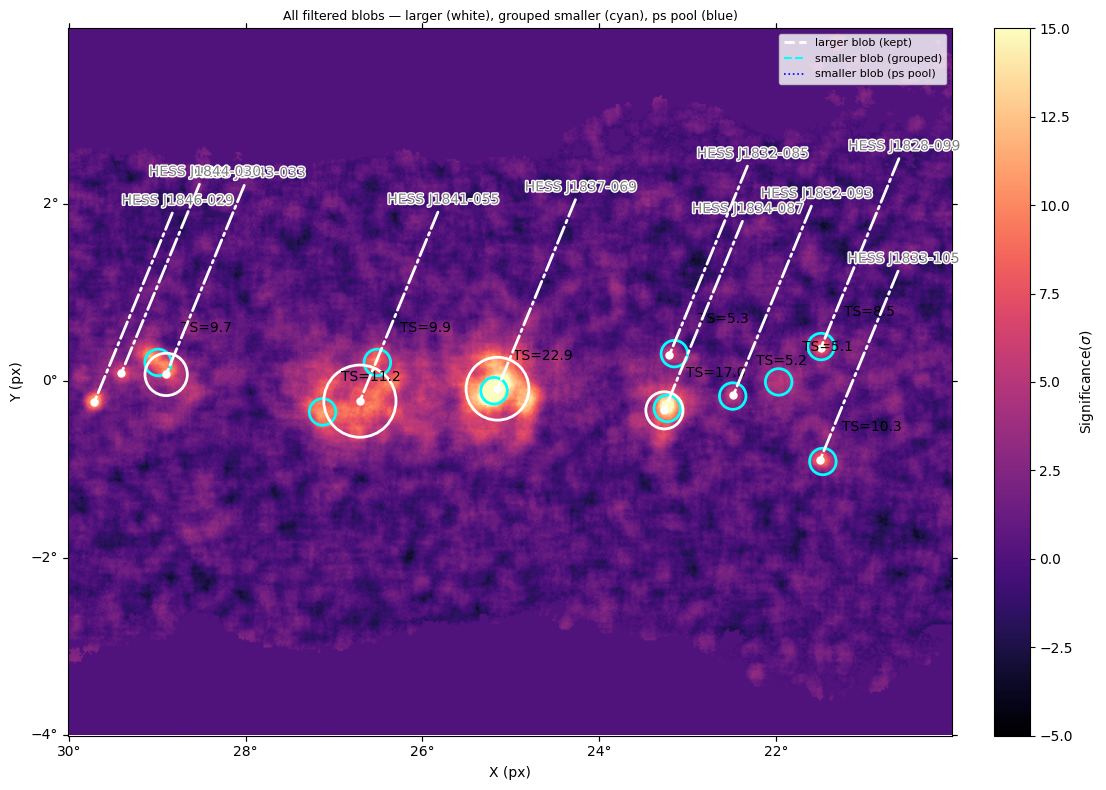

In [39]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection=wcs)
im = ax.imshow(array, cmap='magma', vmin=-5, vmax=15)
plt.colorbar(im, ax=ax, label=r'Significance($\sigma$)', fraction=0.046, pad=0.04)
# ── larger blobs from filtered_groups ────────────────────────────────────────
for lb in ext_filtered_group:
    ly, lx, lr = lb
    ly, lx = int(ly), int(lx)
    center_intensity_lb = array[ly, lx]

    circle_l = plt.Circle((lx, ly), lr, fill=False,
                           edgecolor='black', linewidth=2.0, linestyle='--')
    ax.add_patch(circle_l)
    ax.scatter(lx, ly, s=80, c='black', marker='*', zorder=5)
    ax.text(lx, ly + lr + 10, f'TS={center_intensity_lb:.1f}',
            color='white', fontsize=10, ha='center')


# ── standalone smaller blobs in ps_filtered_group ────────────────────────────
for sb in ps_filtered_group:
    # print(sb[0][0])
    try:
        sy, sx, sr = sb
    except:
        sy, sx, sr = sb[0][0]
    sy, sx = int(sy), int(sx)
    center_intensity_sb = array[sy, sx]
    circle_s = plt.Circle((sx, sy), sr, fill=False,
                           edgecolor='cyan', linewidth=2, linestyle='-')
    ax.add_patch(circle_s)
    # ax.scatter(sx, sy, s=60, c='blue', marker='*', zorder=5)
    ax.text(sx + sr + 20, sy + sr + 10, f'TS={center_intensity_sb:.1f}',
            color='black', fontsize=10, ha='center')
    # ax.text(sx + sr + 2, sy, f'TS={center_intensity_sb:.1f}',
    #         color='blue', fontsize=6, ha='center')

# ── legend handles ────────────────────────────────────────────────────────────
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color='white',  linewidth=2,   linestyle='--', label='larger blob (kept)'),
    Line2D([0], [0], color='cyan',   linewidth=1.5, linestyle='--', label='smaller blob (grouped)'),
    Line2D([0], [0], color='blue',   linewidth=1.2, linestyle=':',  label='smaller blob (ps pool)'),
]
plot_hgps(ax, wcs, pixel_size)
# plot_4hwc1D(ax, wcs, pixel_size)
ax.set_xlim(0, xnum)
ax.set_ylim(0, ynum)
ax.legend(handles=legend_handles, fontsize=8, loc='upper right')
ax.set_title('All filtered blobs — larger (white), grouped smaller (cyan), ps pool (blue)', fontsize=9)
ax.set_xlabel('X (px)')
ax.set_ylabel('Y (px)')
plt.tight_layout()
plt.show()